In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## reading file 
df=pd.read_csv('datalab_export_2026-07-08 23_47_16.csv',lineterminator='\n')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description\r
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.describe()

,release_year
count,100.000000
mean,2015.110000
std,10.167183
min,1975.000000
25%,2013.000000
50%,2021.000000
75%,2021.000000
max,2021.000000


In [5]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [14]:
df.head()

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [ ]:
## drpping the not required columns
cols=['description\r','cast','date_added','director']
df.drop(cols, axis=1,inplace=True)


KeyError: "['description\\r', 'cast', 'date_added', 'director'] not found in axis"

In [15]:
df.head()

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [16]:
df['rating']

0     PG-13
1     TV-MA
2     TV-MA
3     TV-MA
4     TV-MA
      ...  
95    TV-MA
96    TV-MA
97    TV-Y7
98     TV-Y
99    TV-MA
Name: rating, Length: 100, dtype: object

In [17]:
df['listed_in']

0                                         Documentaries
1       International TV Shows, TV Dramas, TV Mysteries
2     Crime TV Shows, International TV Shows, TV Act...
3                                Docuseries, Reality TV
4     International TV Shows, Romantic TV Shows, TV ...
                            ...                        
95                                           Reality TV
96                      Documentaries, Music & Musicals
97           Kids' TV, TV Comedies, TV Sci-Fi & Fantasy
98                           British TV Shows, Kids' TV
99                               TV Comedies, TV Dramas
Name: listed_in, Length: 100, dtype: object

In [ ]:
# diffrentiating genre
df['listed_in']=df['listed_in'].str.split(', ')
df=df.explode('listed_in').reset_index(drop=True)
df.head()

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,International TV Shows
2,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,TV Dramas
3,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,TV Mysteries
4,s3,TV Show,Ganglands,NaN,2021,TV-MA,1 Season,Crime TV Shows


In [20]:
#casting coloumn into category
df['listed_in']=df['listed_in'].astype('category')
df['listed_in'].dtype

CategoricalDtype(categories=['Action & Adventure', 'Anime Features', 'Anime Series',
                  'British TV Shows', 'Children & Family Movies',
                  'Classic Movies', 'Comedies', 'Crime TV Shows',
                  'Documentaries', 'Docuseries', 'Dramas', 'Horror Movies',
                  'Independent Movies', 'International Movies',
                  'International TV Shows', 'Kids' TV', 'Korean TV Shows',
                  'Music & Musicals', 'Reality TV', 'Romantic Movies',
                  'Romantic TV Shows', 'Sci-Fi & Fantasy',
                  'Spanish-Language TV Shows', 'Sports Movies',
                  'TV Action & Adventure', 'TV Comedies', 'TV Dramas',
                  'TV Horror', 'TV Mysteries', 'TV Sci-Fi & Fantasy',
                  'TV Thrillers', 'Thrillers'],
, ordered=False, categories_dtype=object)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       226 non-null    object  
 1   type          226 non-null    object  
 2   title         226 non-null    object  
 3   country       141 non-null    object  
 4   release_year  226 non-null    int64   
 5   rating        226 non-null    object  
 6   duration      226 non-null    object  
 7   listed_in     226 non-null    category
dtypes: category(1), int64(1), object(6)
memory usage: 14.0+ KB


### visualization


In [23]:
sns.set_style('whitegrid')

In [22]:
df['listed_in'].describe

<bound method NDFrame.describe of 0               Documentaries
1      International TV Shows
2                   TV Dramas
3                TV Mysteries
4              Crime TV Shows
                ...          
221       TV Sci-Fi & Fantasy
222          British TV Shows
223                  Kids' TV
224               TV Comedies
225                 TV Dramas
Name: listed_in, Length: 226, dtype: category
Categories (32, object): ['Action & Adventure', 'Anime Features', 'Anime Series', 'British TV Shows', ..., 'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Thrillers']>

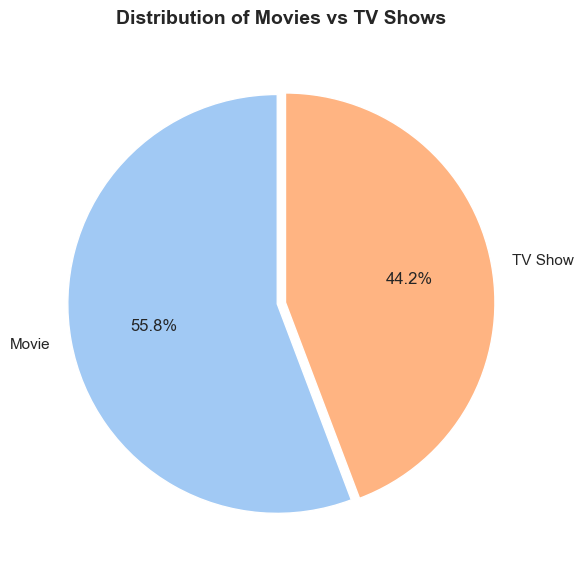

In [33]:
counts = df['type'].value_counts()
labels = counts.index
sizes = counts.values

# Seaborn styling
sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')[0:len(labels)]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02] * len(labels),  # small gap between slices
    shadow=False
)
plt.title('Distribution of Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

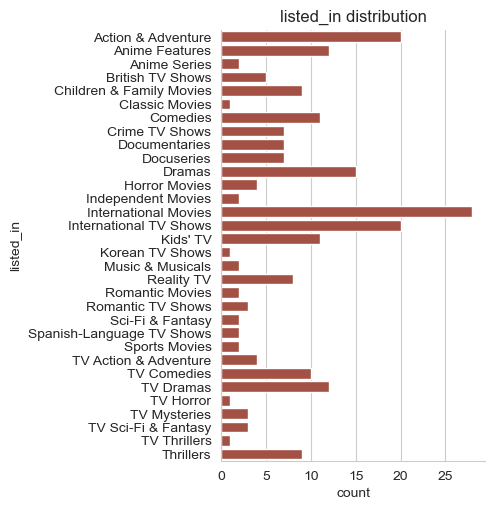

In [ ]:
sns.catplot(y= 'listed_in',data=df,kind='count',
            color='#B34634')
plt.title('listed_in distribution')
plt.show()

In [27]:
df.head()

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,International TV Shows
2,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,TV Dramas
3,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,TV Mysteries
4,s3,TV Show,Ganglands,NaN,2021,TV-MA,1 Season,Crime TV Shows


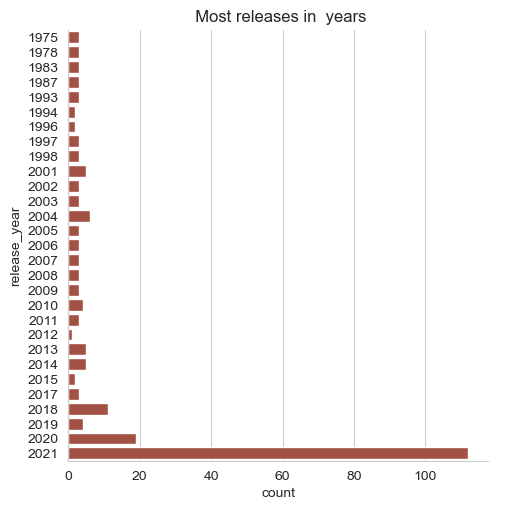

In [30]:
sns.catplot(y= 'release_year',data=df,kind='count',
            color='#B34634')
plt.title('  Most releases in  years ')
plt.show()

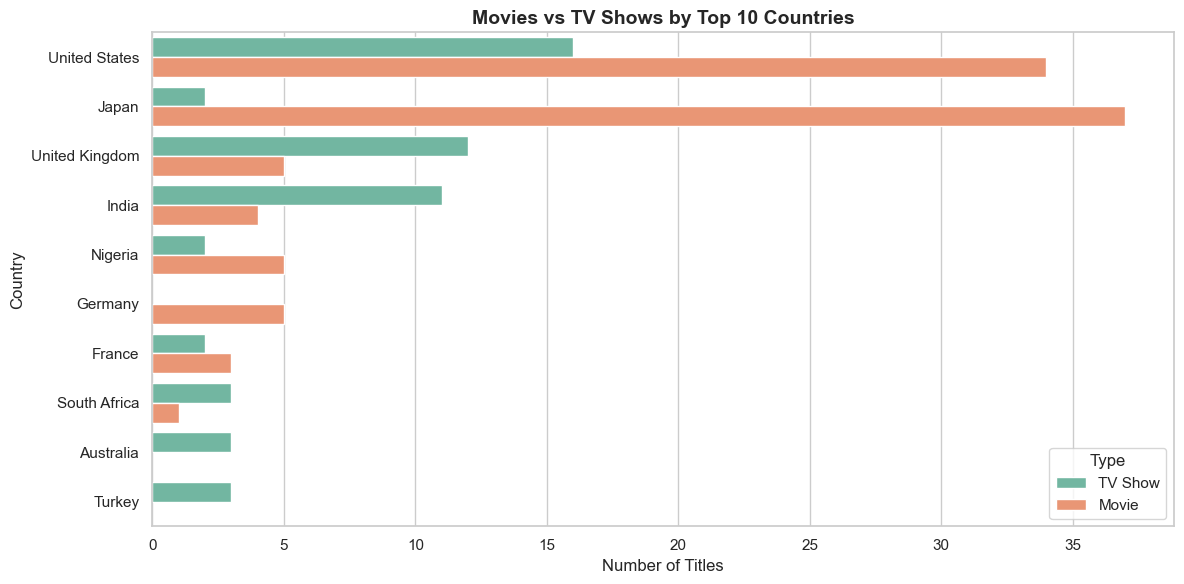

In [ ]:

df_country = df.dropna(subset=['country'])

df_country = df_country.assign(country=df_country['country'].str.split(', ')).explode('country')

top_10_countries = df_country['country'].value_counts().head(10).index

df_top = df_country[df_country['country'].isin(top_10_countries)]

country_type_counts = df_top.groupby(['country', 'type']).size().reset_index(name='count')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(
    data=country_type_counts,
    x='count',
    y='country',
    hue='type',
    palette='Set2',
    order=top_10_countries  

plt.title('Movies vs TV Shows by Top 10 Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

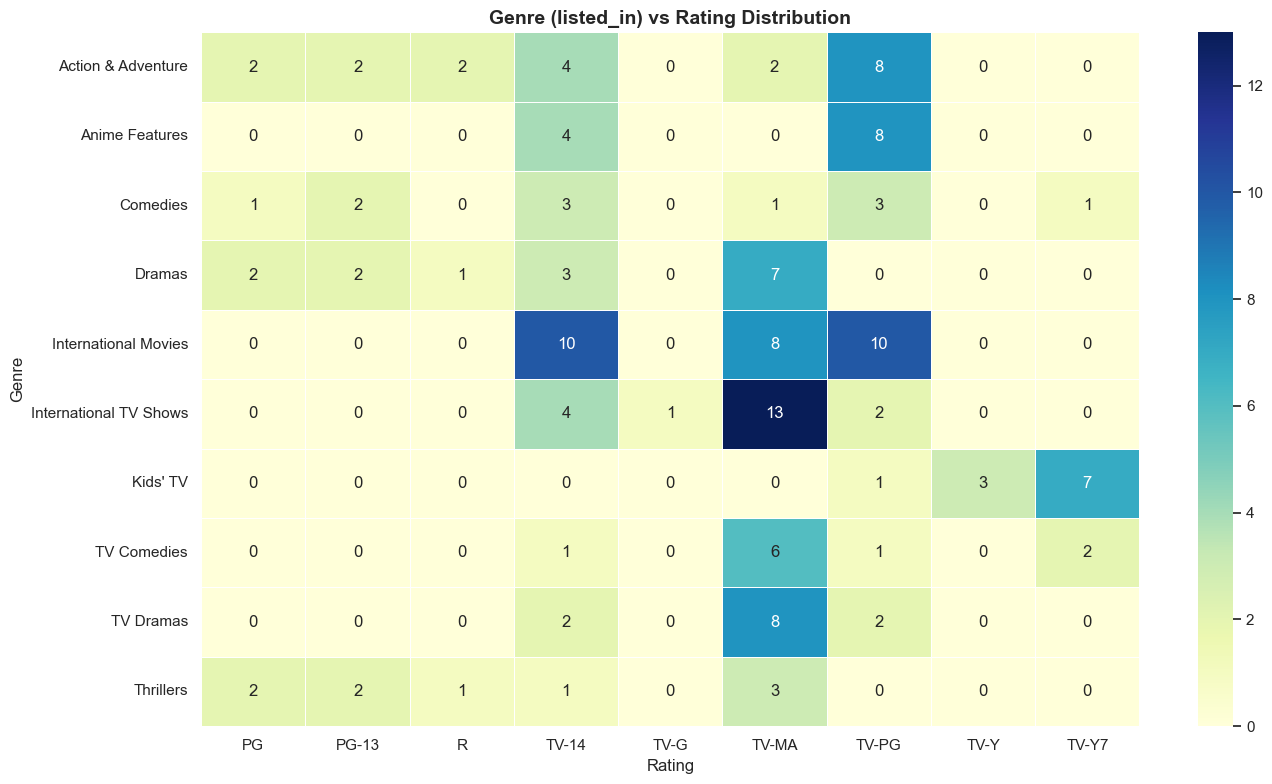

In [35]:

df_clean = df.dropna(subset=['listed_in', 'rating'])

df_clean = df_clean.assign(listed_in=df_clean['listed_in'].str.split(', ')).explode('listed_in')

top_genres = df_clean['listed_in'].value_counts().head(10).index
df_top = df_clean[df_clean['listed_in'].isin(top_genres)]

genre_rating = pd.crosstab(df_top['listed_in'], df_top['rating'])
sns.set_theme(style="white")
plt.figure(figsize=(14, 8))
sns.heatmap(genre_rating, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)

plt.title('Genre (listed_in) vs Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()